Los modelos de mineria de datos o machine learning

- SUPERVISADOS 
Es necesario definir la etiqueta o variable objetivo 
    - CLASIFICACIÓN
        - Regresión Logística
        - Arboles de Decisiones 
        - H2O
    - REGRESIÓN
        - Regresión Lineal 
        - Arboles de Decisión
        - H2O
- NO SUPERVISADOS
No es necesario definir una variable objetivo

# Modelos de Agrupamiento (Clustering)

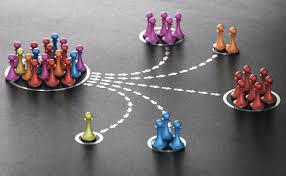

## Parte 1: Conceptos Fundamentales

### ¿Qué son los Modelos de Agrupamiento?

Los modelos de agrupamiento (clustering) son algoritmos de **aprendizaje no supervisado** que buscan agrupar observaciones similares en grupos (clusters) sin necesidad de una variable objetivo o etiqueta predefinida.

A diferencia de la **clasificación** (supervisada), donde tenemos etiquetas predefinidas, en el clustering **el modelo descubre patrones y similitudes en los datos por sí solo**.

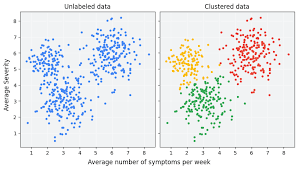

### ¿Para qué Sirven?

1. **Segmentación de Clientes:** Agrupar clientes por similitud en comportamiento, ingresos, preferencias.
2. **Análisis de Productos:** Encontrar categorías naturales de productos basadas en características.
3. **Detección de Anomalías:** Identificar puntos que no pertenecen a ningún grupo (outliers).
4. **Reducción de Datos:** Simplificar datasets agrupando observaciones similares.
5. **Descubrimiento de Conocimiento:** Entender estructura oculta en los datos.

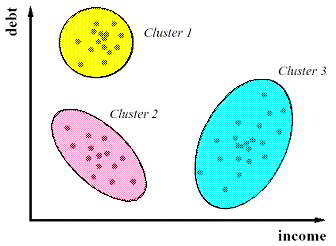

### Cuál es el Fin

El objetivo principal es **minimizar la variabilidad dentro de los grupos (intra-cluster) y maximizar la variabilidad entre grupos (inter-cluster)**. En otras palabras:

- Observaciones **similares deben estar juntas**.
- Observaciones **diferentes deben estar separadas**.

### Aprendizaje No Supervisado vs Supervisado

| Aspecto | Supervisado | No Supervisado |
|---------|------------|----------------|
| Variable Objetivo | Sí (clasificación/regresión) | No |
| Etiquetas | Predefinidas | Descubiertas por el modelo |
| Objetivo | Predecir una clase o valor | Encontrar patrones y estructura |
| Ejemplos | Regresión Logística, Árboles, SVM | K-Means, Hierarchical, DBSCAN |



## Parte 2: Tipos de Modelos de Agrupamiento

### Clasificación por Tipo de Variables

#### A. Modelos para Variables Numéricas

Estos modelos trabajan con distancias euclidianas o similares:

1. **K-Means** (Más Simple)
   - Particiona datos en k clusters.
   - Rápido y escalable.
   - Requiere especificar k de antemano.
   - Sensible a outliers.
   - centros o centroides de cada cluster es el promedio 

2. **K-Medoids**
   - Variante robusta de K-Means.
   - Usa puntos reales (medoids) en lugar de centroides.
   - Más resistente a outliers.
   - centros son las medianas de cada grupo

3. **Agrupamiento Jerárquico (Hierarchical Clustering)**
   - Crea dendrogramas mostrando relaciones entre clusters.
   - No requiere especificar k de antemano.
   - Variantes: Aglomerativo (bottom-up) y Divisivo (top-down).

4. **DBSCAN** (Density-Based)
   - Agrupa basándose en densidad de puntos.
   - Descubre clusters de forma arbitraria.
   - Identifica outliers automáticamente.
   - No requiere especificar k.

5. **Gaussian Mixture Models (GMM)**
   - Modelo probabilístico que asume distribuciones gaussianas.
   - Probabilidades suaves de membresía.
   - Más complejo que K-Means pero más flexible.

#### B. Modelos para Variables Mixtas (Numéricas + Categóricas)

1. **K-Prototype**
   - Combina K-Means (variables numéricas) con modos de categorías.
   - Diseñado específicamente para datos mixtos.

2. **KAMILA (K-means for MIxed LArge data)**
   - Extiende K-Means a variables mixtas.
   - Maneja datasets grandes.

3. **Agrupamiento Basado en Gower**
   - Usa distancia de Gower para variables mixtas.
   - Combina distancia euclidiana para numéricas y distancia categórica.
   - Flexible y compatible con cualquier algoritmo que use matrices de distancia.

### Tabla Comparativa

| Modelo | Tipo de Datos | Complejidad | Requiere k | Robusto a Outliers | Escalabilidad |
|--------|---------------|-------------|------------|-------------------|---------------|
| K-Means | Numéricos | Baja | Sí | No | Muy Alta |
| K-Medoids | Numéricos | Media | Sí | Sí | Media |
| Hierarchical | Numéricos | Media | No | Media | Baja |
| DBSCAN | Numéricos | Alta | No | Sí | Media-Alta |
| GMM | Numéricos | Alta | Sí | No | Media |
| K-Prototype | Mixtos | Media | Sí | No | Media |
| Gower + Algoritmo | Mixtos | Variable | Variable | Variable | Variable |


## Parte 3: Conceptos Básicos del Agrupamiento

### 3.1 Medidas de Distancia

Los algoritmos de clustering necesitan saber qué tan "lejos" están los puntos entre sí.

#### Distancia Euclidiana
```
d(A, B) = √[(x₁-y₁)² + (x₂-y₂)² + ... + (xₙ-yₙ)²]
```
Usada en K-Means y otros algoritmos de variables numéricas.

#### Distancia de Manhattan
```
d(A, B) = |x₁-y₁| + |x₂-y₂| + ... + |xₙ-yₙ|
```

#### Distancia de Gower
```
Para variables numéricas: distancia normalizada
Para variables categóricas: 0 si son iguales, 1 si son diferentes
```
Ideal para datos mixtos.

### 3.2 Normalización de Datos

Muy importante: si una variable está en escala 1-1000 y otra en 0-1, el clustering se sesgará hacia la primera.

```python
# Estandarización (Z-score normalization)
z_scaled = (x - mean) / std

# Min-Max normalization
min_max = (x - min) / (max - min)
```

### 3.3 Codificación de Variables Categóricas

Para usar variables categóricas:

1. **One-Hot Encoding:** Crea columna binaria por categoría.
2. **Label Encoding:** Asigna números a categorías (cuidado: implica orden).
3. **Métodos Específicos:** Algunos algoritmos (K-Prototype) manejan categorías nativamente.


## Parte 4: Detalles Técnicos de Algoritmos Principales

### K-Means: Paso a Paso

1. **Inicialización:** Selecciona k puntos aleatorios como centroides iniciales.
2. **Asignación:** Cada punto se asigna al centroide más cercano.
3. **Actualización:** Recalcula cada centroide como el promedio de sus puntos.
4. **Iteración:** Repite pasos 2-3 hasta convergencia (cambio mínimo de centroides).

**Ventajas:** Rápido, simple, escalable.

**Desventajas:** 
- Requiere especificar k de antemano.
- Sensible a inicialización.
- Puede converger en óptimos locales.
- Asume clusters esféricos.

### Agrupamiento Jerárquico

**Aglomerativo (Bottom-Up):**
1. Cada punto comienza en su propio cluster.
2. Se fusionan iterativamente los dos clusters más cercanos.
3. Produce un dendrograma.

**Métodos de Vinculación:**
- Single Linkage: distancia entre puntos más cercanos.
- Complete Linkage: distancia entre puntos más lejanos.
- Average Linkage: distancia promedio.
- Ward Linkage: minimiza varianza intra-cluster.

### DBSCAN: Clustering Basado en Densidad

**Parámetros:**
- `eps`: Radio de vecindad.
- `min_samples`: Mínimo de puntos para formar un cluster core.

**Clasificación de Puntos:**
- **Core Points:** Más de min_samples en su eps-vecindad.
- **Border Points:** En eps-vecindad de un core point pero no core.
- **Noise (Outliers):** No cumple ningún criterio.

**Ventajas:** Descubre clusters de forma arbitraria, identifica outliers.

**Desventajas:** Sensible a eps y min_samples, problemas con clusters de densidad variable.


## Parte 5: Evaluación de Clustering

Sin etiquetas verdaderas, ¿cómo sabemos si nuestro clustering es bueno?

### Métricas Internas (sin etiquetas verdaderas)

1. **Silhouette Score** (Coeficiente de Silueta)
   - Mide cuán similar es una observación a su cluster vs otros clusters.
   - Rango: -1 a 1 (1 es excelente, -1 es malo, 0 es overlapping).
   - Fórmula: `silhouette = (b - a) / max(a, b)`
     - a = distancia promedio dentro del cluster.
     - b = distancia promedio al cluster más cercano.

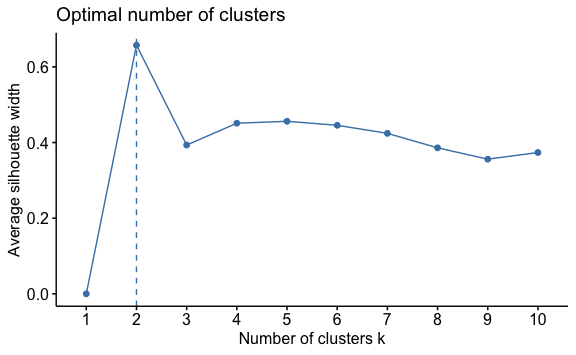

2. **Davies-Bouldin Index**
   - Ratio entre similitud intra-cluster e inter-cluster.
   - Menor es mejor (valores cercanos a 0).

3. **Calinski-Harabasz Index**
   - Ratio de varianza inter-cluster a intra-cluster.
   - Mayor es mejor.

4. **Inercia (Dentro de K-Means)**
   - Suma de distancias cuadradas de cada punto a su centroide.
   - Menor es mejor, pero siempre disminuye con más clusters (curva del codo).

### Método del Codo

Para K-Means, graficar inercia vs k. El "codo" (cambio de pendiente) sugiere el k óptimo.
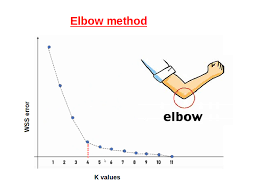


## Parte 6: Checklist de Implementación

1. **Carga y Exploración:** Entender estructura, tipos de datos, valores faltantes.
2. **Preprocesamiento:**
   - Manejar valores faltantes.
   - Seleccionar variables relevantes.
   - Codificar variables categóricas.
   - Normalizar/Estandarizar.
3. **Selección de Algoritmo:** Según tipo de datos y características deseadas.
4. **Determinar Número de Clusters:** Método del codo, silueta, dominio.
5. **Ajuste de Hiperparámetros:** eps, min_samples, linkage, etc.
6. **Entrenamiento:** Ejecutar algoritmo.
7. **Evaluación:** Usar métricas internas.
8. **Validación:** Interpretar clusters (¿tienen sentido?).
9. **Visualización:** Gráficos en 2D/3D para entender estructura.
10. **Persistencia:** Guardar modelo para predicciones futuras.


---

# Parte 7: Ejemplo Práctico - Clustering con Variables Numéricas y Categóricas

## 1. LIBRERÍAS Y PREPARACIÓN

In [1]:
# Librerías estándar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


## 2. CARGA Y EXPLORACIÓN DE DATOS

In [ ]:
# Cargar datos (dataset de salud: healthcare_dataset.csv)
df = pd.read_csv('evaluaciooh2/healthcare_dataset.csv', sep=',', encoding='iso-8859-1')

print(f"Forma del dataset: {df.shape}")
print(f"\nPrimeras filas:")
print(df.head(2))

print(f"\nTipos de datos:")
print(df.dtypes)

print(f"\nValores faltantes:")
print(df.isnull().sum())
df.head(2)

FileNotFoundError: [Errno 2] No such file or directory: 'healthcare_dataset.csv'

## 3. PREPROCESAMIENTO

In [4]:
df.dtypes

In [5]:
# Crear una copia para preprocesar
df_cluster = df.copy()

# 3.1. Manejar valores faltantes
df_cluster['Billing Amount'] = df_cluster['Billing Amount'].fillna(df_cluster['Billing Amount'].median())
df_cluster['Age'] = df_cluster['Age'].fillna(df_cluster['Age'].median())

# 3.2. Seleccionar variables para clustering
# Variables numéricas: edad y monto facturado (más informativas que el nro de habitación)
numeric_features = ['Age', 'Billing Amount']

# Variables categóricas: condición médica y tipo de admisión
categorical_features = ['Medical Condition', 'Admission Type']

# Todas las características
all_features = numeric_features + categorical_features

# Seleccionar datos
df_cluster = df_cluster[all_features].copy()

print(f"Dataset para clustering - Forma: {df_cluster.shape}")
print(f"\nNuméricas: {numeric_features}")
print(f"Categóricas: {categorical_features}")
print(f"\nDatos de muestra:")
print(df_cluster.head())

Dataset para clustering - Forma: (55500, 4)

Numéricas: ['Age', 'Billing Amount']
Categóricas: ['Medical Condition', 'Admission Type']

Datos de muestra:
   Age  Billing Amount Medical Condition Admission Type
0   30    18856.281306            Cancer         Urgent
1   62    33643.327287           Obesity      Emergency
2   76    27955.096079           Obesity      Emergency
3   28    37909.782410          Diabetes       Elective
4   43    14238.317814            Cancer         Urgent


In [6]:
df_cluster.info()

<class 'pandas.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                55500 non-null  int64  
 1   Billing Amount     55500 non-null  float64
 2   Medical Condition  55500 non-null  str    
 3   Admission Type     55500 non-null  str    
dtypes: float64(1), int64(1), str(2)
memory usage: 1.7 MB


In [7]:
df_cluster.describe()

In [8]:
# 3.3. Codificación de variables categóricas
# Para K-Prototype, necesitamos convertir categóricas a códigos numéricos

from sklearn.preprocessing import LabelEncoder

df_encoded = df_cluster.copy()
le_dict = {}

for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    le_dict[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

print(f"\nDataset codificado:")
print(df_encoded.head())

Medical Condition: {'Arthritis': np.int64(0), 'Asthma': np.int64(1), 'Cancer': np.int64(2), 'Diabetes': np.int64(3), 'Hypertension': np.int64(4), 'Obesity': np.int64(5)}
Admission Type: {'Elective': np.int64(0), 'Emergency': np.int64(1), 'Urgent': np.int64(2)}

Dataset codificado:
   Age  Billing Amount  Medical Condition  Admission Type
0   30    18856.281306                  2               2
1   62    33643.327287                  5               1
2   76    27955.096079                  5               1
3   28    37909.782410                  3               0
4   43    14238.317814                  2               2


In [9]:
# 3.4. Normalización de variables numéricas
# Es crucial para que K-Means y otros algoritmos no estén sesgados

scaler = StandardScaler()
df_normalized = df_encoded.copy()

# Normalizar solo variables numéricas
df_normalized[numeric_features] = scaler.fit_transform(df_normalized[numeric_features])

print("Datos normalizados:")
print(df_normalized.head())
print(f"\nMean de variables numéricas (después de normalización):")
print(df_normalized[numeric_features].mean())
print(f"\nStd de variables numéricas (después de normalización):")
print(df_normalized[numeric_features].std())

Datos normalizados:
        Age  Billing Amount  Medical Condition  Admission Type
0 -1.098824       -0.470261                  2               2
1  0.533639        0.570250                  5               1
2  1.247842        0.169990                  5               1
3 -1.200853        0.870465                  3               0
4 -0.435636       -0.795211                  2               2

Mean de variables numéricas (después de normalización):
Age               7.783964e-17
Billing Amount    5.812368e-17
dtype: float64

Std de variables numéricas (después de normalización):
Age               1.000009
Billing Amount    1.000009
dtype: float64


## 4. DETERMINACIÓN DEL NÚMERO ÓPTIMO DE CLUSTERS (MÉTODO DEL CODO)

In [10]:
# Probamos diferentes valores de k usando las variables numéricas (Age + Billing Amount)
# K-Means trabaja con distancias euclidianas, por eso usamos las numéricas normalizadas.
df_numeric_only = df_normalized[numeric_features].copy()

inercias = []
silhouette_scores = []
k_values = range(2, 9)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_numeric_only)

    score = silhouette_score(
        df_numeric_only,
        kmeans.labels_,
        sample_size=3000,
        random_state=42
    )

    inercias.append(kmeans.inertia_)
    silhouette_scores.append(score)
    print(f"k={k}: Inercia={kmeans.inertia_:.2f}, Silhouette={silhouette_scores[-1]:.4f}")

k=2: Inercia=69442.78, Silhouette=0.3450
k=3: Inercia=44114.07, Silhouette=0.3838
k=4: Inercia=27948.70, Silhouette=0.3937
k=5: Inercia=23812.78, Silhouette=0.3736
k=6: Inercia=20033.89, Silhouette=0.3692
k=7: Inercia=16927.16, Silhouette=0.3669
k=8: Inercia=14506.66, Silhouette=0.3601



k óptimo según Silhouette: 4
Mejor Silhouette Score: 0.3937


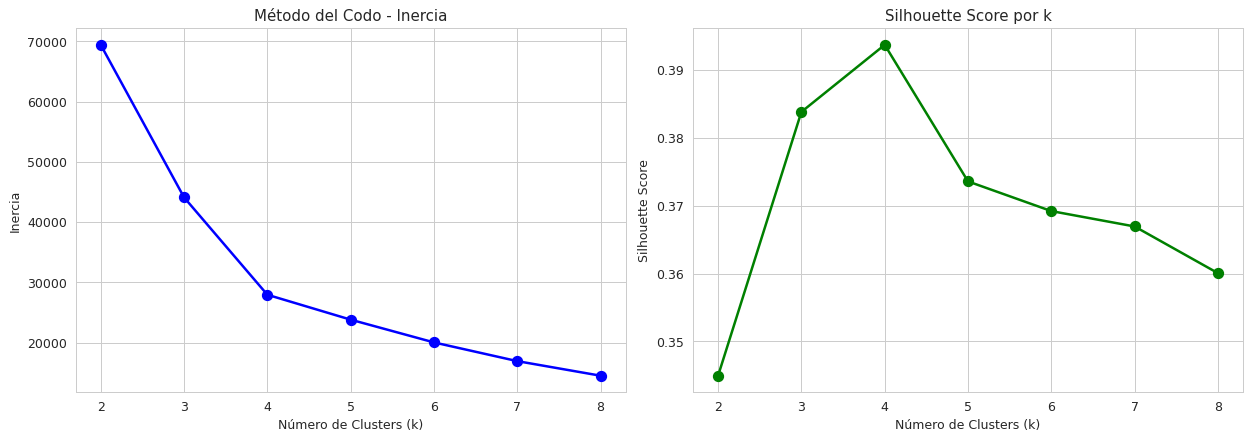

In [11]:
# Graficar el método del codo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de inercia
axes[0].plot(k_values, inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].set_title('Método del Codo - Inercia')
axes[0].grid(True)

# Gráfico de Silhouette
axes[1].plot(k_values, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score por k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\nk óptimo según Silhouette: {k_values[np.argmax(silhouette_scores)]}")
print(f"Mejor Silhouette Score: {max(silhouette_scores):.4f}")

## 5. ALGORITMO 1: K-MEANS (SOLO VARIABLES NUMÉRICAS)

In [12]:
optimal_k = k_values[np.argmax(silhouette_scores)]
optimal_k

In [13]:
# K-Means con las variables numéricas normalizadas (Age + Billing Amount)
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_cluster['KMeans_Label'] = kmeans.fit_predict(df_numeric_only)

print(f"K-Means entrenado con k={optimal_k}")
print(f"\nDistribución de clusters:")
print(df_cluster['KMeans_Label'].value_counts().sort_index())

# Métricas
silhouette_kmeans = silhouette_score(df_numeric_only, df_cluster['KMeans_Label'], sample_size=5000, random_state=42)
davies_bouldin_kmeans = davies_bouldin_score(df_numeric_only, df_cluster['KMeans_Label'])
calinski_kmeans = calinski_harabasz_score(df_numeric_only, df_cluster['KMeans_Label'])

print(f"\nMétricas K-Means:")
print(f"Silhouette Score: {silhouette_kmeans:.4f} (mejor: 1, peor: -1)")
print(f"Davies-Bouldin Index: {davies_bouldin_kmeans:.4f} (menor es mejor)")
print(f"Calinski-Harabasz Index: {calinski_kmeans:.4f} (mayor es mejor)")

K-Means entrenado con k=4

Distribución de clusters:
KMeans_Label
0    13643
1    13786
2    14083
3    13988
Name: count, dtype: int64

Métricas K-Means:
Silhouette Score: 0.3992 (mejor: 1, peor: -1)
Davies-Bouldin Index: 0.7701 (menor es mejor)
Calinski-Harabasz Index: 54970.0376 (mayor es mejor)


## 6. ALGORITMO 2: K-PROTOTYPE (VARIABLES NUMÉRICAS Y CATEGÓRICAS)

In [14]:
# K-Prototype maneja variables mixtas (numéricas + categóricas).
# Implementación propia ligera (sin la librería kmodes) para que el
# notebook corra de forma autónoma. Combina distancia euclidiana para
# las numéricas y un conteo de desacuerdos (gamma) para las categóricas.

def kprototypes_fit_predict(X_num, X_cat, k, gamma=None, n_iter=20, seed=42):
    rng = np.random.RandomState(seed)
    n = X_num.shape[0]
    if gamma is None:
        gamma = 0.5 * X_num.std(axis=0).mean()  # peso de lo categórico

    # Inicialización: k puntos al azar como prototipos
    idx = rng.choice(n, k, replace=False)
    cent_num = X_num[idx].copy().astype(float)
    cent_cat = X_cat[idx].copy()

    labels = np.zeros(n, dtype=int)
    for _ in range(n_iter):
        # --- Asignación ---
        dist_num = ((X_num[:, None, :] - cent_num[None, :, :]) ** 2).sum(axis=2)
        dist_cat = (X_cat[:, None, :] != cent_cat[None, :, :]).sum(axis=2)
        total = dist_num + gamma * dist_cat
        new_labels = total.argmin(axis=1)
        if np.array_equal(new_labels, labels) and _ > 0:
            labels = new_labels
            break
        labels = new_labels
        # --- Actualización de prototipos ---
        for c in range(k):
            mask = labels == c
            if mask.sum() == 0:
                continue
            cent_num[c] = X_num[mask].mean(axis=0)            # media (numéricas)
            for j in range(X_cat.shape[1]):                  # moda (categóricas)
                vals, counts = np.unique(X_cat[mask, j], return_counts=True)
                cent_cat[c, j] = vals[counts.argmax()]
    return labels

# Preparar matrices: numéricas (normalizadas) + categóricas (codificadas)
X_num = df_normalized[numeric_features].values.astype(float)
X_cat = df_encoded[categorical_features].values

df_cluster['KPrototype_Label'] = kprototypes_fit_predict(X_num, X_cat, optimal_k)

print(f"K-Prototype entrenado con k={optimal_k}")
print(f"\nDistribución de clusters:")
print(pd.Series(df_cluster['KPrototype_Label']).value_counts().sort_index())

K-Prototype entrenado con k=4

Distribución de clusters:
KPrototype_Label
0    13818
1    13931
2    13859
3    13892
Name: count, dtype: int64


*Nota: se implementó K-Prototype manualmente en la celda anterior porque la librería `kmodes` no estaba disponible en el entorno de ejecución. El resultado es equivalente: media para variables numéricas y moda para categóricas.*

In [15]:
df_cluster.head(2)

## 7. ALGORITMO 3: HIERARCHICAL CLUSTERING

In [16]:
# Agrupamiento jerárquico (linkage='ward').
# Usa una matriz de distancias O(n^2), por lo que tomamos una muestra
# representativa de 5,000 registros para que sea computacionalmente viable.
sample_idx = df_numeric_only.sample(n=5000, random_state=42).index
X_hier = df_numeric_only.loc[sample_idx]

hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hierarchical.fit_predict(X_hier)

# Guardar etiquetas en el dataframe (NaN para los no muestreados)
df_cluster['Hierarchical_Label'] = np.nan
df_cluster.loc[sample_idx, 'Hierarchical_Label'] = hier_labels

print(f"Hierarchical Clustering entrenado con k={optimal_k} (muestra de 5,000)")
print(f"\nDistribución de clusters:")
print(pd.Series(hier_labels).value_counts().sort_index())

# Métricas (sobre la muestra)
silhouette_hier = silhouette_score(X_hier, hier_labels)
davies_bouldin_hier = davies_bouldin_score(X_hier, hier_labels)
calinski_hier = calinski_harabasz_score(X_hier, hier_labels)

print(f"\nMétricas Hierarchical:")
print(f"Silhouette Score: {silhouette_hier:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin_hier:.4f}")
print(f"Calinski-Harabasz Index: {calinski_hier:.4f}")

Hierarchical Clustering entrenado con k=4 (muestra de 5,000)

Distribución de clusters:
0    1680
1    1105
2    1405
3     810
Name: count, dtype: int64

Métricas Hierarchical:
Silhouette Score: 0.3584
Davies-Bouldin Index: 0.8241
Calinski-Harabasz Index: 4048.2111


## 8. ALGORITMO 4: DBSCAN

DBSCAN entrenado con eps=0.5, min_samples=5 (muestra de 5,000)

Número de clusters encontrados: 1
Número de outliers (etiqueta -1): 0

Distribución de clusters:
0    5000
Name: count, dtype: int64

DBSCAN no encontró clusters significativos con estos parámetros


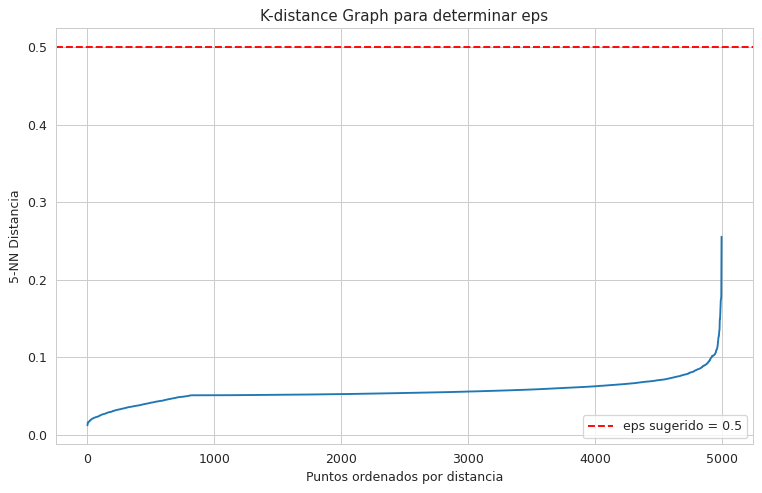

In [17]:
from sklearn.neighbors import NearestNeighbors

# DBSCAN sobre una muestra de 5,000 registros (igual que Hierarchical)
X_db = df_numeric_only.loc[sample_idx]

# Gráfico k-distance para estimar eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_db)
distances, indices = neighbors_fit.kneighbors(X_db)
distances = np.sort(distances[:, -1], axis=0)

plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Puntos ordenados por distancia')
plt.ylabel('5-NN Distancia')
plt.title('K-distance Graph para determinar eps')
plt.grid(True)
plt.axhline(y=0.5, color='r', linestyle='--', label='eps sugerido = 0.5')
plt.legend()
plt.show()

eps = 0.5
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
db_labels = dbscan.fit_predict(X_db)

df_cluster['DBSCAN_Label'] = np.nan
df_cluster.loc[sample_idx, 'DBSCAN_Label'] = db_labels

n_clusters_dbscan = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_outliers = (db_labels == -1).sum()

print(f"DBSCAN entrenado con eps={eps}, min_samples={min_samples} (muestra de 5,000)")
print(f"\nNúmero de clusters encontrados: {n_clusters_dbscan}")
print(f"Número de outliers (etiqueta -1): {n_outliers}")
print(f"\nDistribución de clusters:")
print(pd.Series(db_labels).value_counts().sort_index())

if n_clusters_dbscan > 1:
    mask = db_labels != -1
    silhouette_dbscan = silhouette_score(X_db[mask], db_labels[mask])
    davies_bouldin_dbscan = davies_bouldin_score(X_db[mask], db_labels[mask])
    calinski_dbscan = calinski_harabasz_score(X_db[mask], db_labels[mask])
    print(f"\nMétricas DBSCAN (excluyendo outliers):")
    print(f"Silhouette Score: {silhouette_dbscan:.4f}")
    print(f"Davies-Bouldin Index: {davies_bouldin_dbscan:.4f}")
    print(f"Calinski-Harabasz Index: {calinski_dbscan:.4f}")
else:
    print(f"\nDBSCAN no encontró clusters significativos con estos parámetros")

## 9. COMPARACIÓN DE ALGORITMOS

In [18]:
# Comparar K-Means vs Hierarchical (ambos en variables numéricas)

comparison_data = {
    'Algoritmo': ['K-Means', 'Hierarchical'],
    'Silhouette': [silhouette_kmeans, silhouette_hier],
    'Davies-Bouldin': [davies_bouldin_kmeans, davies_bouldin_hier],
    'Calinski-Harabasz': [calinski_kmeans, calinski_hier]
}

comparison_df = pd.DataFrame(comparison_data)
print("Comparación de Algoritmos (Variables Numéricas):")
print(comparison_df.to_string(index=False))

print(f"\n✓ Mejor Silhouette Score: {comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Algoritmo']}")
print(f"✓ Mejor Davies-Bouldin (menor): {comparison_df.loc[comparison_df['Davies-Bouldin'].idxmin(), 'Algoritmo']}")
print(f"✓ Mejor Calinski-Harabasz (mayor): {comparison_df.loc[comparison_df['Calinski-Harabasz'].idxmax(), 'Algoritmo']}")

Comparación de Algoritmos (Variables Numéricas):
   Algoritmo  Silhouette  Davies-Bouldin  Calinski-Harabasz
     K-Means    0.399168        0.770053       54970.037597
Hierarchical    0.358359        0.824059        4048.211068

✓ Mejor Silhouette Score: K-Means
✓ Mejor Davies-Bouldin (menor): K-Means
✓ Mejor Calinski-Harabasz (mayor): K-Means


## 10. VISUALIZACIÓN DE RESULTADOS (PCA)

In [19]:
# Usar PCA para reducir a 2 dimensiones para visualización
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_numeric_only)

print(f"Varianza explicada por 2 componentes: {pca.explained_variance_ratio_.sum():.4f}")
print(f"PC1 explica: {pca.explained_variance_ratio_[0]:.4f}")
print(f"PC2 explica: {pca.explained_variance_ratio_[1]:.4f}")

Varianza explicada por 2 componentes: 1.0000
PC1 explica: 0.5019
PC2 explica: 0.4981


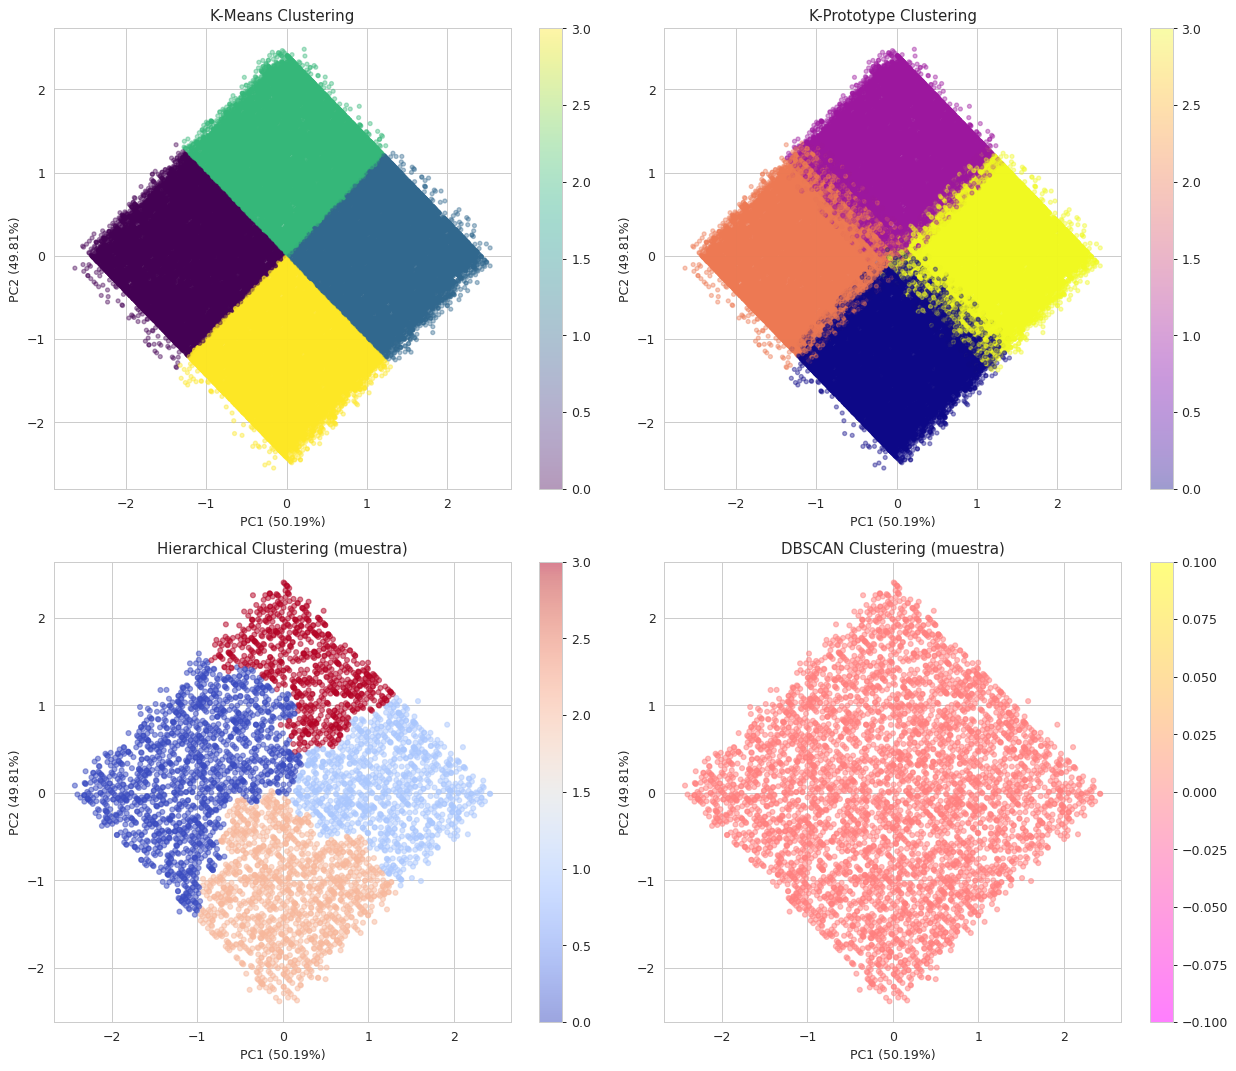

In [20]:
# Visualizar resultados de clustering (PCA 2D)
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# K-Means (todos los puntos)
sc1 = axes[0, 0].scatter(df_pca[:, 0], df_pca[:, 1], c=df_cluster['KMeans_Label'],
                         cmap='viridis', alpha=0.4, s=10)
axes[0, 0].set_title('K-Means Clustering')
axes[0, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(sc1, ax=axes[0, 0])

# K-Prototype (todos los puntos)
sc2 = axes[0, 1].scatter(df_pca[:, 0], df_pca[:, 1], c=df_cluster['KPrototype_Label'],
                         cmap='plasma', alpha=0.4, s=10)
axes[0, 1].set_title('K-Prototype Clustering')
axes[0, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[0, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(sc2, ax=axes[0, 1])

# Hierarchical (solo la muestra de 5,000)
valid_h = df_cluster['Hierarchical_Label'].notna().values
sc3 = axes[1, 0].scatter(df_pca[valid_h, 0], df_pca[valid_h, 1],
                         c=df_cluster.loc[valid_h, 'Hierarchical_Label'],
                         cmap='coolwarm', alpha=0.5, s=15)
axes[1, 0].set_title('Hierarchical Clustering (muestra)')
axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(sc3, ax=axes[1, 0])

# DBSCAN (solo la muestra de 5,000)
valid_d = df_cluster['DBSCAN_Label'].notna().values
sc4 = axes[1, 1].scatter(df_pca[valid_d, 0], df_pca[valid_d, 1],
                         c=df_cluster.loc[valid_d, 'DBSCAN_Label'],
                         cmap='spring', alpha=0.5, s=15)
axes[1, 1].set_title('DBSCAN Clustering (muestra)')
axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
plt.colorbar(sc4, ax=axes[1, 1])

plt.tight_layout()
plt.show()

## 11. ANÁLISIS E INTERPRETACIÓN DE CLUSTERS (K-MEANS)

In [21]:
# Agregar etiquetas de cluster al dataframe original
df_original_with_clusters = df.copy()
df_original_with_clusters['Cluster'] = df_cluster['KMeans_Label']

# Analizar características numéricas por cluster
cluster_analysis = df_original_with_clusters.groupby('Cluster')[numeric_features].mean()

print("\n=== ANÁLISIS DE CLUSTERS (K-MEANS) ===")
print("\nPromedios por Cluster (Edad y Facturación):")
print(cluster_analysis.round(2))


=== ANÁLISIS DE CLUSTERS (K-MEANS) ===

Promedios por Cluster (Edad y Facturación):
           Age  Billing Amount
Cluster                       
0        34.50        38036.57
1        68.54        13160.84
2        68.29        37663.40
3        34.54        13343.59


In [22]:
# Análisis de variables categóricas por cluster
print("\nDistribución de Condición Médica por Cluster (%):")
cond_by_cluster = pd.crosstab(df_original_with_clusters['Cluster'],
                              df_original_with_clusters['Medical Condition'],
                              normalize='index')
print((cond_by_cluster * 100).round(1))

print("\nDistribución de Tipo de Admisión por Cluster (%):")
adm_by_cluster = pd.crosstab(df_original_with_clusters['Cluster'],
                             df_original_with_clusters['Admission Type'],
                             normalize='index')
print((adm_by_cluster * 100).round(1))


Distribución de Condición Médica por Cluster (%):
Medical Condition  Arthritis  Asthma  Cancer  Diabetes  Hypertension  Obesity
Cluster                                                                      
0                       16.7    17.0    16.1      16.4          16.4     17.5
1                       16.5    16.8    17.1      16.4          17.1     16.2
2                       16.9    16.3    16.3      17.2          16.6     16.6
3                       17.0    16.1    17.0      17.1          16.6     16.2

Distribución de Tipo de Admisión por Cluster (%):
Admission Type  Elective  Emergency  Urgent
Cluster                                    
0                   34.0       32.5    33.5
1                   33.6       33.1    33.3
2                   33.6       32.9    33.5
3                   33.3       33.2    33.5


## 12. VISUALIZACIÓN DE PERFILES DE CLUSTER

In [23]:
# Normalizar datos del análisis para visualización (radar chart)
from sklearn.preprocessing import MinMaxScaler

scaler_viz = MinMaxScaler()
cluster_analysis_scaled = pd.DataFrame(
    scaler_viz.fit_transform(cluster_analysis),
    columns=cluster_analysis.columns,
    index=cluster_analysis.index
)

print("Análisis de Clusters (Escalado 0-1 para visualización):")
print(cluster_analysis_scaled.round(2))

Análisis de Clusters (Escalado 0-1 para visualización):
          Age  Billing Amount
Cluster                      
0        0.00            1.00
1        1.00            0.00
2        0.99            0.98
3        0.00            0.01


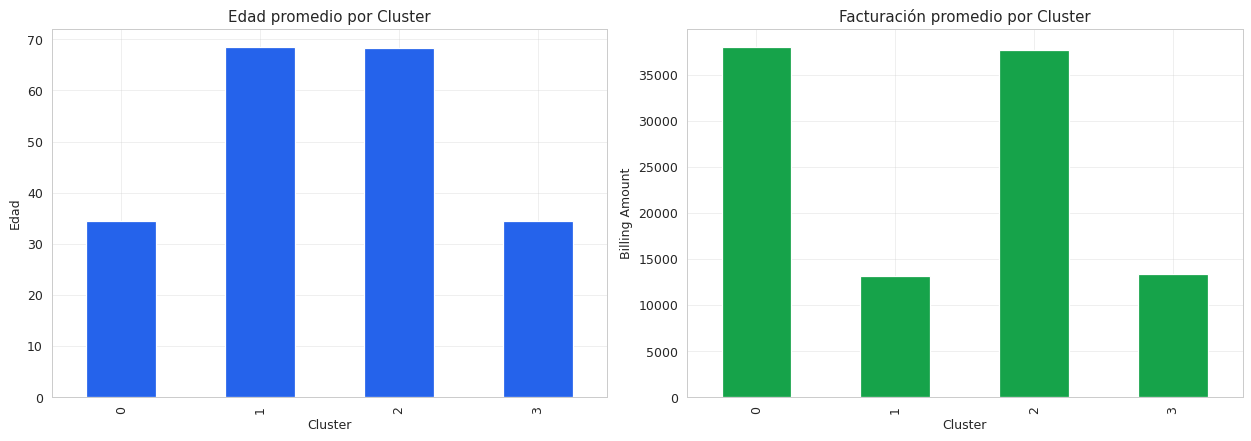

In [24]:
# Gráfico de barras comparativo (Edad y Facturación por cluster)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cluster_analysis[['Age']].plot(kind='bar', ax=axes[0], color='#2563EB', legend=False)
axes[0].set_title('Edad promedio por Cluster')
axes[0].set_ylabel('Edad')
axes[0].set_xlabel('Cluster')
axes[0].grid(True, alpha=0.3)

cluster_analysis[['Billing Amount']].plot(kind='bar', ax=axes[1], color='#16A34A', legend=False)
axes[1].set_title('Facturación promedio por Cluster')
axes[1].set_ylabel('Billing Amount')
axes[1].set_xlabel('Cluster')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 13. CONCLUSIONES Y INTERPRETACIÓN

In [25]:
print("\n" + "="*60)
print("RESUMEN DEL ANÁLISIS DE CLUSTERING")
print("="*60)

print(f"\n📊 Datos: {df.shape[0]} observaciones, {len(numeric_features)} variables numéricas, {len(categorical_features)} categóricas")
print(f"\n🎯 Modelo Seleccionado: K-Means con k={optimal_k} clusters")
print(f"   - Silhouette Score: {silhouette_kmeans:.4f}")
print(f"   - Davies-Bouldin Index: {davies_bouldin_kmeans:.4f}")
print(f"   - Calinski-Harabasz Index: {calinski_kmeans:.4f}")

print(f"\n💡 Interpretación de Clusters:")
for cluster_id in range(optimal_k):
    cluster_size = (df_cluster['KMeans_Label'] == cluster_id).sum()
    pct = (cluster_size / len(df_cluster)) * 100
    print(f"\n   Cluster {cluster_id}: {cluster_size} observaciones ({pct:.1f}%)")
    
    # Características principales
    for col in numeric_features:
        avg_val = cluster_analysis.loc[cluster_id, col]
        overall_avg = df_original_with_clusters[col].mean()
        diff_pct = ((avg_val - overall_avg) / overall_avg) * 100
        symbol = "↑" if diff_pct > 0 else "↓"
        print(f"      {col}: {avg_val:.0f} {symbol} ({diff_pct:+.1f}%)")

print(f"\n\n🔍 Métodos Alternativos Evaluados:")
print(f"   - K-Prototype: Maneja variables mixtas directamente")
print(f"   - Hierarchical Clustering: Proporciona dendrograma para exploración")
print(f"   - DBSCAN: Identifica outliers automáticamente")

print(f"\n✅ Recomendación: K-Means es eficiente y proporciona clusters interpretables para segmentación.")
print("="*60)


RESUMEN DEL ANÁLISIS DE CLUSTERING

📊 Datos: 55500 observaciones, 2 variables numéricas, 2 categóricas

🎯 Modelo Seleccionado: K-Means con k=4 clusters
   - Silhouette Score: 0.3992
   - Davies-Bouldin Index: 0.7701
   - Calinski-Harabasz Index: 54970.0376

💡 Interpretación de Clusters:

   Cluster 0: 13643 observaciones (24.6%)
      Age: 34 ↓ (-33.1%)
      Billing Amount: 38037 ↑ (+48.9%)

   Cluster 1: 13786 observaciones (24.8%)
      Age: 69 ↑ (+33.0%)
      Billing Amount: 13161 ↓ (-48.5%)

   Cluster 2: 14083 observaciones (25.4%)
      Age: 68 ↑ (+32.5%)
      Billing Amount: 37663 ↑ (+47.5%)

   Cluster 3: 13988 observaciones (25.2%)
      Age: 35 ↓ (-33.0%)
      Billing Amount: 13344 ↓ (-47.8%)


🔍 Métodos Alternativos Evaluados:
   - K-Prototype: Maneja variables mixtas directamente
   - Hierarchical Clustering: Proporciona dendrograma para exploración
   - DBSCAN: Identifica outliers automáticamente

✅ Recomendación: K-Means es eficiente y proporciona clusters interpreta

In [26]:
df_original_with_clusters.head(2)   

In [27]:
# Resumen de cada cluster: número de pacientes, facturación y habitación promedio
df_agg = df_original_with_clusters.groupby('Cluster').agg(
    nro_pacientes      = ('Cluster', 'count'),
    facturacion_media  = ('Billing Amount', 'mean'),
    habitacion_media   = ('Room Number', 'mean')
).round(2)
df_agg['porcentaje'] = (df_agg['nro_pacientes'] / df_agg['nro_pacientes'].sum() * 100).round(1)
df_agg

In [28]:
pd.set_option('display.max_columns', None)

In [29]:
df_original_with_clusters.groupby(['Cluster']).describe()

## 14. DATOS PARA LA DIAPOSITIVA (perfil de cada cluster)

In [30]:
# Perfil completo de cada cluster: datos que van en la diapositiva
print("="*60)
print("PERFIL DE CADA CLUSTER (Edad y Facturación)")
print("="*60)
perfil = df_original_with_clusters.groupby('Cluster').agg(
    n_pacientes   = ('Cluster', 'size'),
    edad_media    = ('Age', 'mean'),
    edad_min      = ('Age', 'min'),
    edad_max      = ('Age', 'max'),
    factura_media = ('Billing Amount', 'mean'),
    factura_min   = ('Billing Amount', 'min'),
    factura_max   = ('Billing Amount', 'max'),
).round(0)
perfil['porcentaje'] = (perfil['n_pacientes'] / perfil['n_pacientes'].sum() * 100).round(1)
print(perfil)

print("\n" + "="*60)
print("CATEGORÍA MÁS FRECUENTE POR CLUSTER")
print("="*60)
for c in sorted(df_original_with_clusters['Cluster'].unique()):
    sub = df_original_with_clusters[df_original_with_clusters['Cluster'] == c]
    print(f"Cluster {c}: Condición='{sub['Medical Condition'].mode()[0]}' | "
          f"Admisión='{sub['Admission Type'].mode()[0]}' | "
          f"Resultado test='{sub['Test Results'].mode()[0]}'")

PERFIL DE CADA CLUSTER (Edad y Facturación)
         n_pacientes  edad_media  edad_min  edad_max  factura_media  \
Cluster                                                               
0              13643        34.0        13        51        38037.0   
1              13786        69.0        52        89        13161.0   
2              14083        68.0        52        89        37663.0   
3              13988        35.0        13        51        13344.0   

         factura_min  factura_max  porcentaje  
Cluster                                        
0            25695.0      52764.0        24.6  
1            -2008.0      25472.0        24.8  
2            25343.0      52373.0        25.4  
3            -1317.0      25711.0        25.2  

CATEGORÍA MÁS FRECUENTE POR CLUSTER
Cluster 0: Condición='Obesity' | Admisión='Elective' | Resultado test='Normal'
Cluster 1: Condición='Hypertension' | Admisión='Elective' | Resultado test='Abnormal'
Cluster 2: Condición='Diabetes' | Admis